In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import LoadImage
from pathlib import PureWindowsPath, Path
import torch
import sys
sys.path.append("/projects/net_contrast_classification/contrast_phase")
from Diffusion.latent_diffusion_v3 import ReconstructionModel as Diffusion_model
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/Preprocessing/Paired_diffusion_data/full_pairs.csv")

In [3]:
inference_data = data[data['split'] == "inference"].reset_index()
inference_data
file_paths = inference_data.iloc[0:5, -1]
sample = torch.load(file_paths[4])
sample

a_img = sample['arterial_image']
p_img = sample['portal_image']
a_liver = sample['arterial_liver']
p_liver = sample['portal_liver']

if a_img is not None:
    print(a_img.shape, a_liver.shape)
else:
    print("No arterial info")
if p_img is not None:
    print(p_img.shape, p_liver.shape)
else:
    print("No portal info")



/tmp/ipykernel_380860/3714956123.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample = torch.load(file_paths[4])


torch.Size([1, 128, 128, 128]) torch.Size([1, 128, 128, 128])
No portal info


In [2]:

model_path = "/projects/net_contrast_classification/contrast_phase/Diffusion/best_diffusion.pth"
model_state=torch.load(model_path, map_location=torch.device("cpu"))

print(type(model_state))


model = Diffusion_model(in_channels=2)
model.load_state_dict(model_state)
model.eval()

/tmp/ipykernel_380860/839415146.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state=torch.load(model_path, map_location=torch.device("cpu"))


<class 'collections.OrderedDict'>


ReconstructionModel(
  (autoencoder): AutoEncoderModel(
    (encoder): UNetEncoder(
      (down1): ConvBlock(
        (net): Sequential(
          (0): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (1): GroupNorm(8, 32, eps=1e-05, affine=True)
          (2): SiLU()
          (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (4): GroupNorm(8, 32, eps=1e-05, affine=True)
          (5): SiLU()
        )
      )
      (down2): ConvBlock(
        (net): Sequential(
          (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (1): GroupNorm(8, 64, eps=1e-05, affine=True)
          (2): SiLU()
          (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (4): GroupNorm(8, 64, eps=1e-05, affine=True)
          (5): SiLU()
        )
      )
      (down3): ConvBlock(
        (net): Sequential(
          (0): Conv3d(64, 128, kernel_size=(3, 3, 

In [4]:
def load_model(model_path):
    model_state=torch.load(model_path, map_location=torch.device("cpu"))
    model = Diffusion_model(in_channels=2)
    model.load_state_dict(model_state)

    return model.eval()

In [ ]:
arterial_input = torch.cat([a_img,a_liver],dim=0)
arterial_input= arterial_input.unsqueeze(dim=0)

generated_pvp = model.generate_image(model, arterial_input)


In [ ]:
print(generated_pvp.shape)
generated_pvp_img = generated_pvp[:, 0:1].squeeze(0)      # preserves channel dimension
generated_pvp_liver = generated_pvp[:, 1:2].squeeze(0)
print(generated_pvp_img.shape, generated_pvp_liver.shape)

torch.Size([1, 2, 128, 128, 128])
torch.Size([1, 128, 128, 128]) torch.Size([1, 128, 128, 128])


In [ ]:
from matplotlib.patches import Patch
def show_images(ap, pvp, generated_pvp, slice_idx, 
                seg_a=None, seg_p=None, seg_generated = None):

    fig, axes = plt.subplots(1, 3, figsize=(12, 6))
    # -------------------------
    # Arterial slice
    # -------------------------

    ct_slice_a = np.rot90(ap[0, :, :, slice_idx], k=1)
    axes[0].imshow(ct_slice_a, cmap="gray")

    if seg_a is not None:
        # lesion_slices_a = np.where(seg_a[0].sum(axis=(0, 1)) > 0)[0]
        mask_a = seg_a[0, :, :, slice_idx] > 0
        rgba_a = np.zeros((*mask_a.shape, 4))
        rgba_a[..., :3] = [1, 0, 0]
        rgba_a[..., 3] = mask_a * 0.5
        axes[0].imshow(np.rot90(rgba_a, k=1))

    axes[0].set_title(f"Arterial slice {slice_idx}", fontsize = 20)
    axes[0].axis("off")

    # -------------------------
    # Portal slice
    # -------------------------

    ct_slice_p = np.rot90(pvp[0, :, :, slice_idx], k=1)
    axes[1].imshow(ct_slice_p, cmap="gray")

    if seg_p is not None:
        # lesion_slices_p = np.where(seg_p[0].sum(axis=(0, 1)) > 0)[0]
        mask_p = seg_p[0, :, :, slice_idx] > 0
        rgba_p = np.zeros((*mask_p.shape, 4))
        rgba_p[..., :3] = [1, 0, 0]
        rgba_p[..., 3] = mask_p * 0.5
        axes[1].imshow(np.rot90(rgba_p, k=1))

    axes[1].set_title(f"Portal slice {slice_idx}", fontsize = 20)
    axes[1].axis("off")

    # -------------------------
    # Generated Portal slice
    # -------------------------

    ct_slice_gp = np.rot90(generated_pvp[0, :, :, slice_idx], k=1)
    axes[2].imshow(ct_slice_gp, cmap="gray")

    if seg_generated is not None:
        # lesion_slices_gp = np.where(seg_p[0].sum(axis=(0, 1)) > 0)[0]
        mask_gp = seg_generated[0, :, :, slice_idx] > 0
        rgba_gp = np.zeros((*mask_gp.shape, 4))
        rgba_gp[..., :3] = [1, 0, 0]
        rgba_gp[..., 3] = mask_gp * 0.5
        axes[2].imshow(np.rot90(rgba_gp, k=1))

    axes[2].set_title(f"Generated Portal slice {slice_idx}", fontsize = 20)
    axes[2].axis("off")

    # -------------------------
    # Legend (shared)
    # -------------------------
    legend_patches = [Patch(color="red", label="Liver")]
    fig.legend(handles=legend_patches, loc="lower left", framealpha=0.8, fontsize=12)

    plt.tight_layout()
    plt.show()

In [5]:
def evaluate_generated_images(data,
                              split,
                              num_samples,
                              sample_idx,
                              model_path,
                              slice_idx = 85):
    
    data_split = data[data['split'] == split].reset_index()
    file_paths = data_split.iloc[0:num_samples, -1]
    sample = torch.load(file_paths[sample_idx])
    a_img = sample['arterial_image']
    p_img = sample['portal_image']
    a_liver = sample['arterial_liver']
    p_liver = sample['portal_liver']

    if a_img is not None:
        print(a_img.shape, a_liver.shape)
    else:
        print("No arterial info")
    if p_img is not None:
        print(p_img.shape, p_liver.shape)
    else:
        print("No portal info")

    model = load_model(model_path)

    arterial_input = torch.cat([a_img,a_liver],dim=0)
    arterial_input= arterial_input.unsqueeze(dim=0)

    generated_pvp = model.generate_image(arterial_input)
    generated_pvp_img = generated_pvp[:, 0:1].squeeze(0)      # preserves channel dimension
    generated_pvp_liver = generated_pvp[:, 1:2].squeeze(0)

    # print(generated_pvp_img.shape, generated_pvp_liver.shape)
    show_images(a_img, p_img, generated_pvp_img, slice_idx)
    
    return a_img, a_liver, p_img, p_liver, generated_pvp_img, generated_pvp_liver

    
    

In [6]:
a_img, a_liver, p_img, p_liver, generated_pvp_img, generated_pvp_liver=evaluate_generated_images(data, "test", 4, 0, model_path, slice_idx=55)

/tmp/ipykernel_380860/3385092442.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample = torch.load(file_paths[sample_idx])


torch.Size([1, 128, 128, 128]) torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128]) torch.Size([1, 128, 128, 128])


/tmp/ipykernel_380860/2446940884.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state=torch.load(model_path, map_location=torch.device("cpu"))


RuntimeError: Given groups=1, weight of size [64, 128, 3, 3, 3], expected input[1, 64, 64, 64, 64] to have 128 channels, but got 64 channels instead

/tmp/ipykernel_2853656/1920225319.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample = torch.load(file_paths[0])


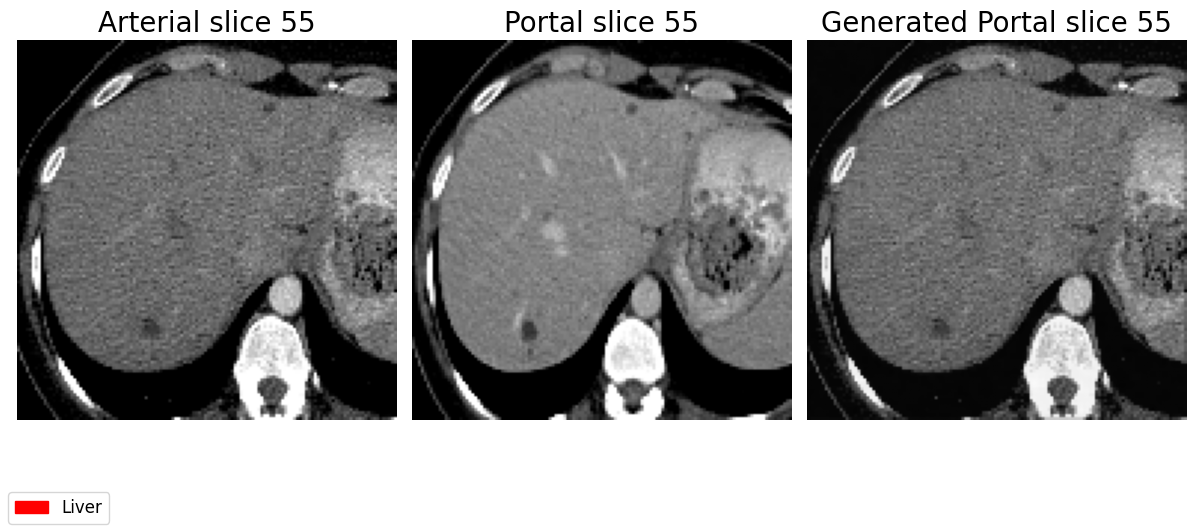

In [ ]:
show_images(a_img, p_img, generated_pvp_img, slice_idx = 55)